In [1]:
from pdb import set_trace
from importlib import reload

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from gfatpy.config import set_logger_level
from gfatpy.lidar.preprocessing import preprocess
from gfatpy.lidar import utils
from gfatpy.utils.utils import moving_average
from gfatpy.lidar.retrieval import klett, raman
from gfatpy.utils.plot import color_list
set_logger_level("WARNING")

%load_ext autoreload
%autoreload 2

%matplotlib inline

### Read data

In [2]:
RS_FL = r"../tests/datos/PRODUCTS/mulhacen/1a/2021/07/05/mhc_1a_Prs_rs_xf_20210705.nc"

lidar = preprocess(RS_FL,
    channels=["532xpa"],
)

### Create a synthetic profile

In [3]:
z = lidar["range"].values
elastic_wavelength = 532
raman_wavelength = 607
output = utils.generate_synthetic_signal(z, wavelength=elastic_wavelength, wavelength_raman=raman_wavelength, 
                                         force_zero_aer_after_bin=1100, k_lidar = 2e11, ae=(1,1), lr=(45,45), synthetic_beta=(-2.5e-6, 5e-6))

In [4]:
ss, ss_raman, params = output

In [5]:
print(params.keys())

dict_keys(['particle_alpha', 'particle_beta', 'molecular_alpha', 'molecular_beta', 'lidar_ratio', 'molecular_beta_att', 'particle_accum_ext', 'molecular_accum_ext', 'transmittance', 'overlap', 'k_lidar', 'angstrom_exponent', 'synthetic_beta', 'ecmwf_data', 'particle_beta_raman', 'particle_alpha_raman', 'molecular_alpha_raman', 'molecular_beta_raman', 'molecular_beta_att_raman', 'particle_accum_ext_raman', 'molecular_accum_ext_raman', 'transmittance_raman', 'molecular_density'])


In [6]:
plt.plot(params["particle_beta"], z)
plt.plot(params["molecular_beta"], z)
plt.ylim((0, 7500))

(0.0, 7500.0)

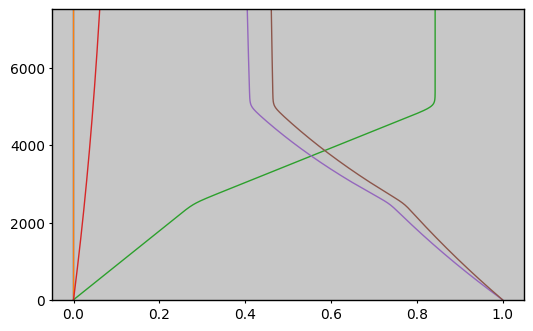

In [7]:
plt.plot(params["particle_accum_ext"], z)
plt.plot(params["molecular_accum_ext"], z)

plt.plot(params["transmittance"], z)
plt.plot(params["transmittance_raman"], z)

plt.ylim((0, 7500))
plt.show()

(0.0, 7500.0)

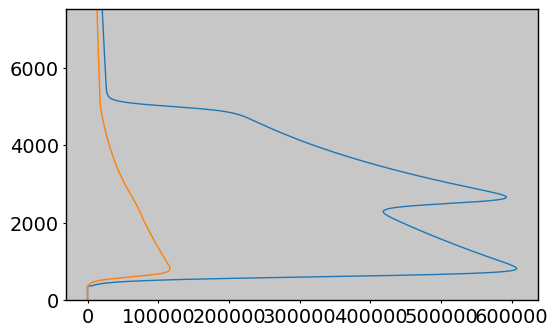

In [8]:
P = ss
plt.plot(ss * z**2, z)
plt.plot(ss_raman * z**2, z)
plt.ylim((0, 7500))

In [9]:
klett.klett_rcs(P * z**2, range_profile = z, beta_mol_profile=params["molecular_beta"])

array([-1.33032370e-06, -1.33034268e-06, -1.33036178e-06, ...,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

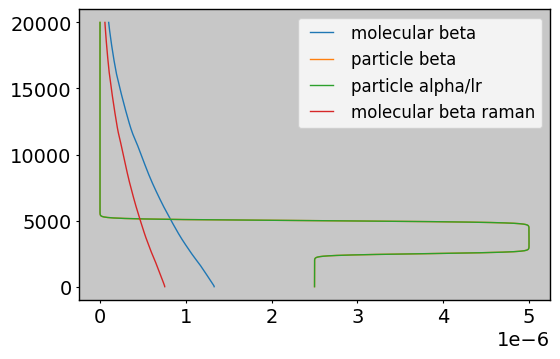

In [10]:
fig, ax = plt.subplots()

ax.plot(params['molecular_beta'], z, label = "molecular beta")
ax.plot(params['particle_beta'], z, label = "particle beta")
ax.plot(params['particle_alpha']/45, z, label = "particle alpha/lr")
ax.plot(params['molecular_beta_raman'], z, label = "molecular beta raman")

ax.legend()

### Rayleigh fit

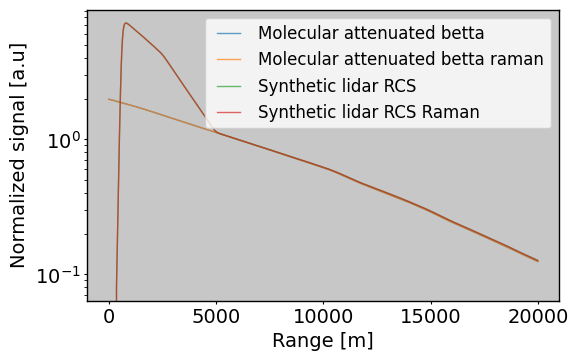

In [11]:
fig, ax = plt.subplots()

att_beta = params["molecular_beta_att"]
att_beta_raman = params["molecular_beta_att_raman"]

#Elastic
P_rcs = P * z**2
beta_att_norm = att_beta / att_beta[np.searchsorted(z, 6000)]
p_norm = P_rcs / P_rcs[np.searchsorted(z, 6000)]

#Raman
P_rcs_raman = ss_raman * z**2
beta_att_norm_raman = att_beta_raman / att_beta_raman[0][np.searchsorted(z, 6000)]
p_norm = P_rcs_raman / P_rcs_raman[np.searchsorted(z, 6000)]

ax.plot(z, beta_att_norm, alpha = 0.7, label = "Molecular attenuated betta")
ax.plot(z, beta_att_norm_raman[0], alpha = 0.7, label = "Molecular attenuated betta raman")

ax.plot(z, p_norm, alpha = 0.7, label = "Synthetic lidar RCS")
ax.plot(z, p_norm, alpha = 0.7, label = "Synthetic lidar RCS Raman")



ax.set(ylabel="Normalized signal [a.u]",xlabel="Range [m]")
ax.set_yscale("log")

ax.legend()


(0.0, 7000.0)

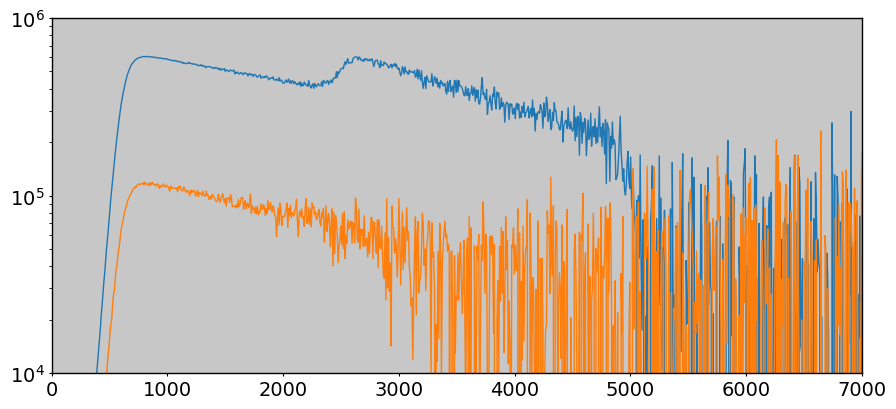

In [12]:
# Add Gaussian noise to the synthetic signal
noise = np.random.normal(0, 0.002, size = P_rcs.shape)
noise_raman = np.random.normal(0, 0.002, size = P_rcs_raman.shape)
ss_noise = ss + noise
ss_raman_noise = ss_raman + noise_raman

fig, ax = plt.subplots(figsize = (10, 5))
plt.plot(z, ss_noise * z**2)
plt.plot(z, ss_raman_noise * z**2)
plt.yscale("log")
plt.ylim((1e4, 1e6))
plt.xlim((0, 7000))


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\3322486.py:16: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(ss_smooth  -ss)/ss, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])


Text(0.5, 0, '')

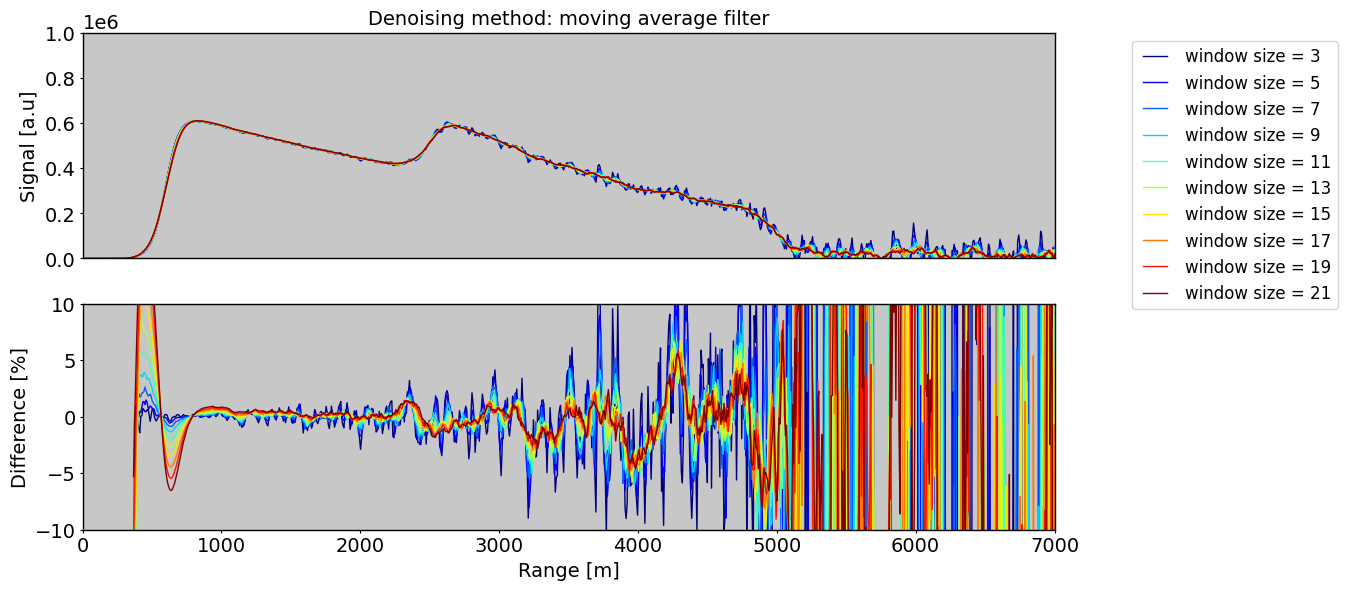

In [13]:
#Definition of moving average fucntion
def moving_average(x, window_size):
    window = np.ones(int(window_size))/float(window_size)
    return np.convolve(x, window, 'same')

#Analysis of the moving average filter for different values of the window size
#Two axis figure to plot the signal and the difference with the original signal
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
window_size_list = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
colors= color_list(len(window_size_list))
for window_size in window_size_list:
    ss_smooth = moving_average(ss_noise, window_size)
    #Axis 1: plot the signal
    ax[0].plot(z, ss_smooth * z**2, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])
    #Axis 2: plot the difference with the original signal
    ax[1].plot(z, 100*(ss_smooth  -ss)/ss, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax[0].set_title("Denoising method: moving average filter")
ax[0].set_xticks([])
ax[0].set_xlabel("")


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\1010501405.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(ss_smooth  -ss)/ss, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])


Text(0.5, 0, '')

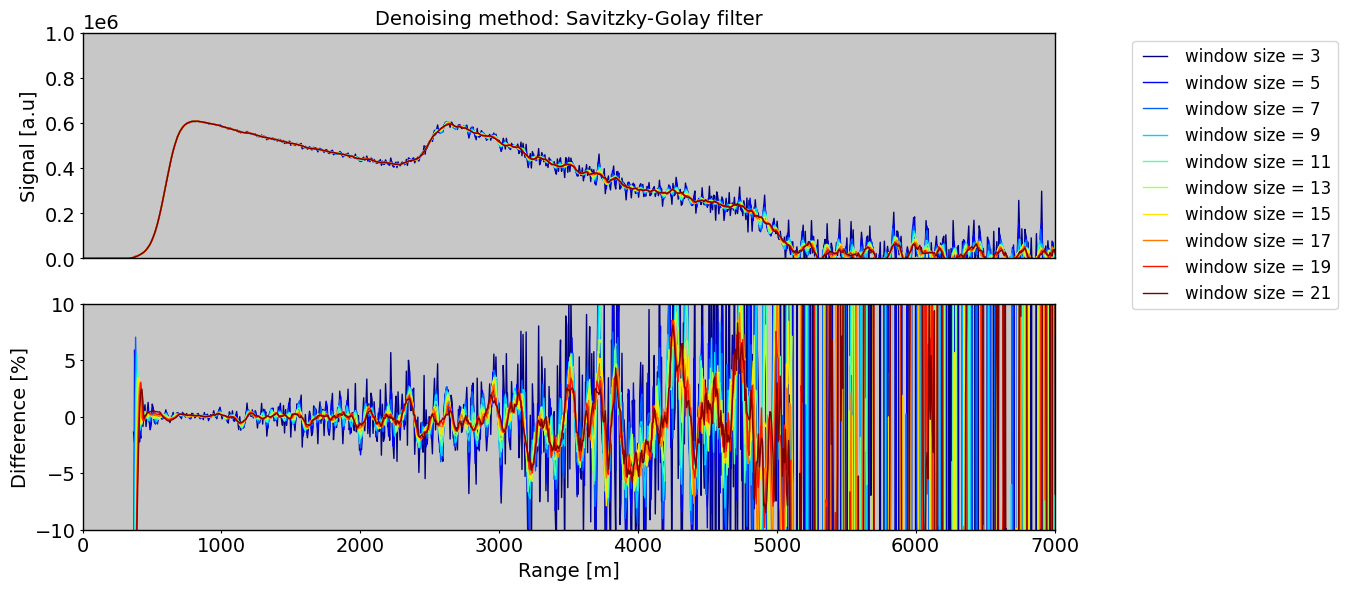

In [14]:
#Analysis of the savgol filter for different values of the window size
#Two axis figure to plot the signal and the difference with the original signal
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
window_size_list = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
colors= color_list(len(window_size_list))
for window_size in window_size_list:
    ss_smooth = savgol_filter(ss_noise, window_size, 2)
    #Axis 1: plot the signal
    ax[0].plot(z, ss_smooth * z**2, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])
    #Axis 2: plot the difference with the original signal
    ax[1].plot(z, 100*(ss_smooth  -ss)/ss, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax[0].set_title("Denoising method: Savitzky-Golay filter")
ax[0].set_xticks([])
ax[0].set_xlabel("")


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\476021233.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(smoothed_signal  -ss)/ss, label = f"sigma = {sigma}", color = colors[sigma_list.index(sigma)])


Text(0.5, 0, '')

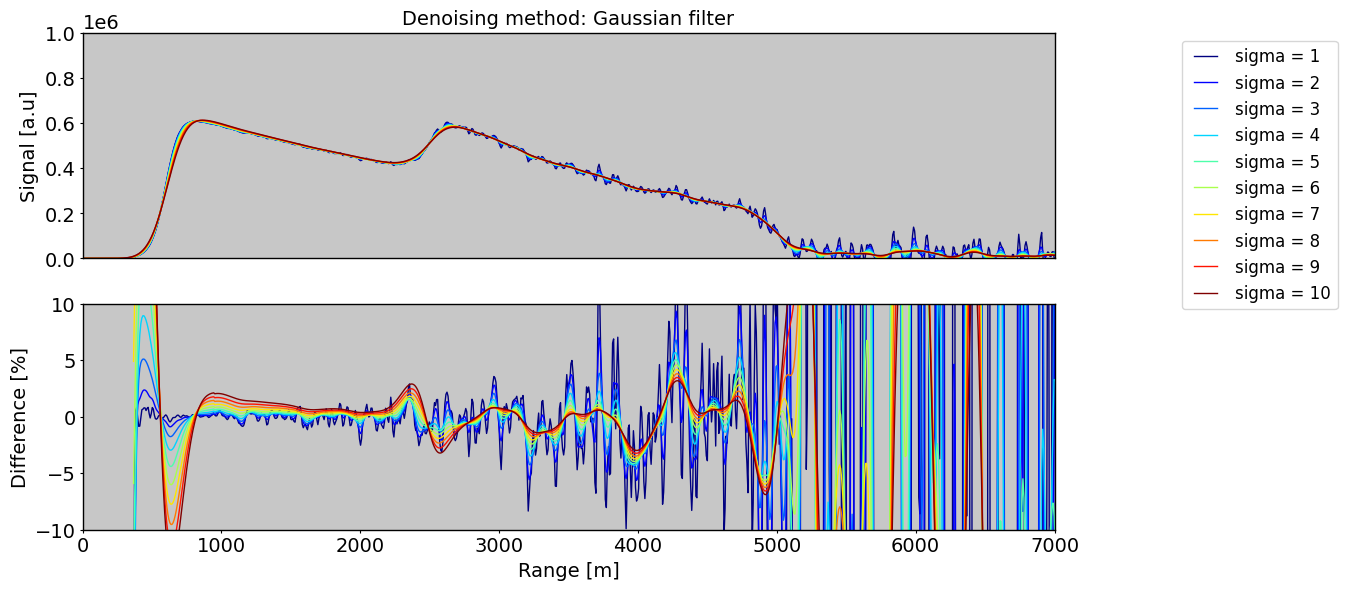

In [15]:
#Analysis of the gaussian filter for different values of the sigma parameter and a window size 
from scipy.ndimage import gaussian_filter1d
sigma_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
colors = color_list(len(sigma_list))
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
for sigma in sigma_list:
    smoothed_signal = gaussian_filter1d(ss_noise, sigma)
    #Axis 1: plot the signal
    ax[0].plot(z, smoothed_signal * z**2, label = f"sigma = {sigma}", color = colors[sigma_list.index(sigma)])
    #Axis 2: plot the difference with the original signal
    ax[1].plot(z, 100*(smoothed_signal  -ss)/ss, label = f"sigma = {sigma}", color = colors[sigma_list.index(sigma)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax[0].set_title("Denoising method: Gaussian filter")
ax[0].set_xticks([])
ax[0].set_xlabel("")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\2682925726.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(ss_smooth  -ss)/ss, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\2682925726.py:11: RuntimeWarning: invalid value encountered in divide
  ax[1].plot(z, 100*(ss_smooth  -ss)/ss, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])


Text(0.5, 0, '')

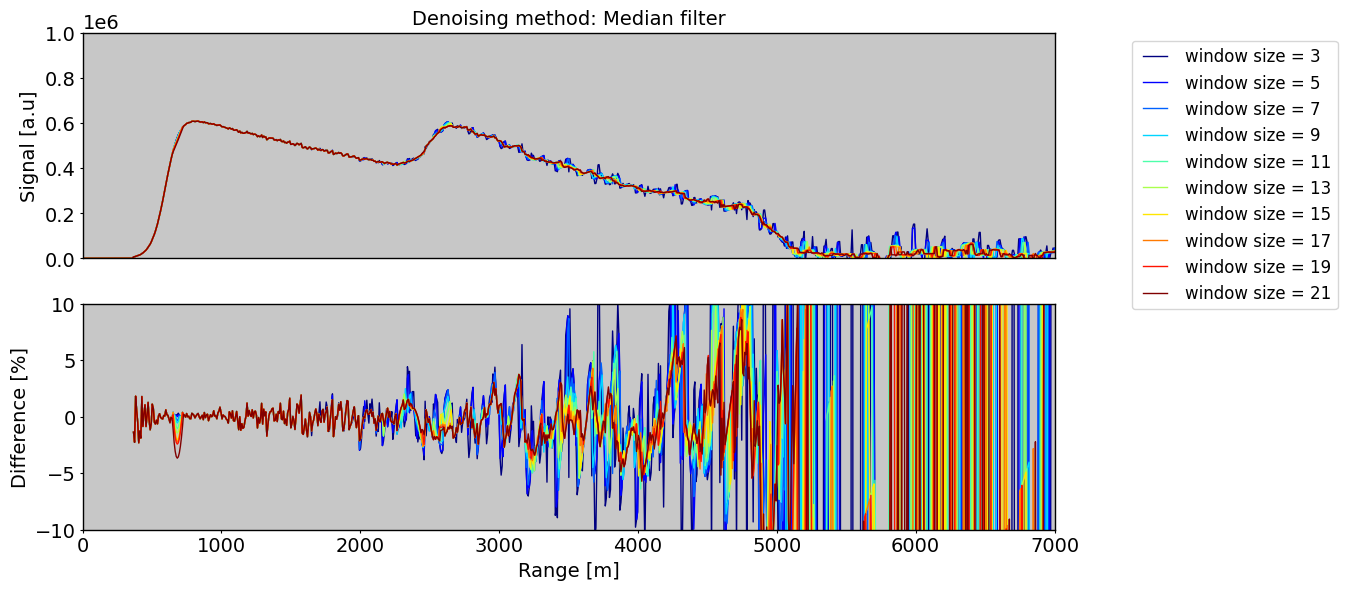

In [16]:
# Analysis of the median filter for different values of the window size
from scipy.signal import medfilt
window_size_list = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
colors = color_list(len(window_size_list))
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
for window_size in window_size_list:
    ss_smooth = medfilt(ss_noise, window_size)
    #Axis 1: plot the signal
    ax[0].plot(z, ss_smooth * z**2, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])
    #Axis 2: plot the difference with the original signal
    ax[1].plot(z, 100*(ss_smooth  -ss)/ss, label = f"window size = {window_size}", c=colors[window_size_list.index(window_size)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax[0].set_title("Denoising method: Median filter")
ax[0].set_xticks([])
ax[0].set_xlabel("")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\2279042276.py:13: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(smoothed_signal  -ss)/ss, label = f"noise = {noise}, ws = {window_size}", color = colors[noise_list.index(noise)*len(window_size_list) + window_size_list.index(window_size)])


Text(0.5, 0, '')

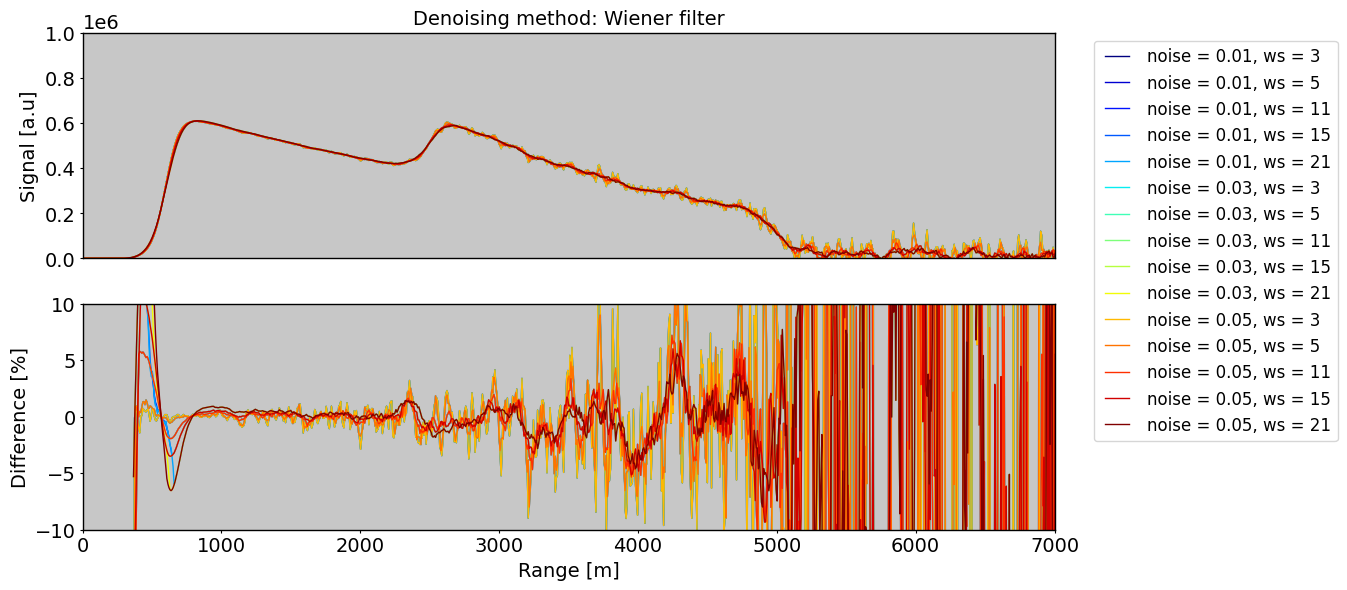

In [17]:
#Analysis of the wiener filter for different values of the noise parameter and a window size
from scipy.signal import wiener
noise_list = [0.01, 0.03, 0.05]
window_size_list = [3, 5, 11, 15, 21]
colors = color_list(len(window_size_list)*len(noise_list))
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
for noise in noise_list:
    for window_size in window_size_list:
        smoothed_signal = wiener(ss_noise, window_size, noise)
        #Axis 1: plot the signal
        ax[0].plot(z, smoothed_signal * z**2, label = f"noise = {noise}, ws = {window_size}", color = colors[noise_list.index(noise)*len(window_size_list) + window_size_list.index(window_size)])
        #Axis 2: plot the difference with the original signal
        ax[1].plot(z, 100*(smoothed_signal  -ss)/ss, label = f"noise = {noise}, ws = {window_size}", color = colors[noise_list.index(noise)*len(window_size_list) + window_size_list.index(window_size)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize = 12)
ax[0].set_title("Denoising method: Wiener filter")
ax[0].set_xticks([])
ax[0].set_xlabel("")



C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\3138886510.py:15: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(smoothed_signal  -ss)/ss, label = f"cutoff = {cutoff}, ws = {window_size}", color = colors[cutoff_list.index(cutoff)*len(window_size_list) + window_size_list.index(window_size)])


Text(0.5, 0, '')

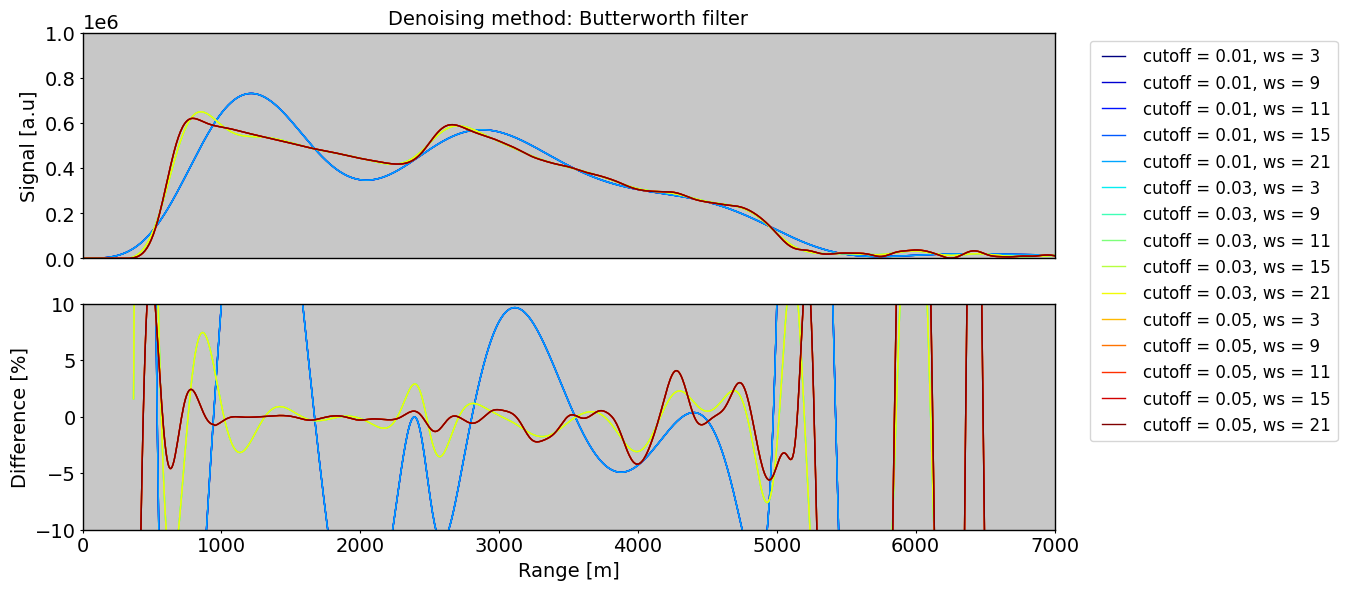

In [18]:
# Analysis of the butterworth filter for different values of the cutoff frequency and a window size
from scipy.signal import butter, filtfilt
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
cutoff_list  = [0.01, 0.03, 0.05]
window_size_list = [3, 9, 11, 15, 21]
number_of_colors = len(cutoff_list) * len(window_size_list)
colors = color_list(number_of_colors )
for cutoff in cutoff_list:
    for window_size in window_size_list:
        b, a = butter(3, cutoff, btype='low', analog=False)
        smoothed_signal = filtfilt(b, a, ss_noise)
        #Axis 1: plot the signal
        ax[0].plot(z, smoothed_signal * z**2, label = f"cutoff = {cutoff}, ws = {window_size}", color = colors[cutoff_list.index(cutoff)*len(window_size_list) + window_size_list.index(window_size)])
        #Axis 2: plot the difference with the original signal
        ax[1].plot(z, 100*(smoothed_signal  -ss)/ss, label = f"cutoff = {cutoff}, ws = {window_size}", color = colors[cutoff_list.index(cutoff)*len(window_size_list) + window_size_list.index(window_size)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize = 12)
ax[0].set_title("Denoising method: Butterworth filter")
ax[0].set_xticks([])
ax[0].set_xlabel("")



C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\3144087617.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(trend  -ss)/ss, label = f"smoothing parameter = {smoothing_parameter}", color = colors[smoothing_parameter_list.index(smoothing_parameter)])


Text(0.5, 0, '')

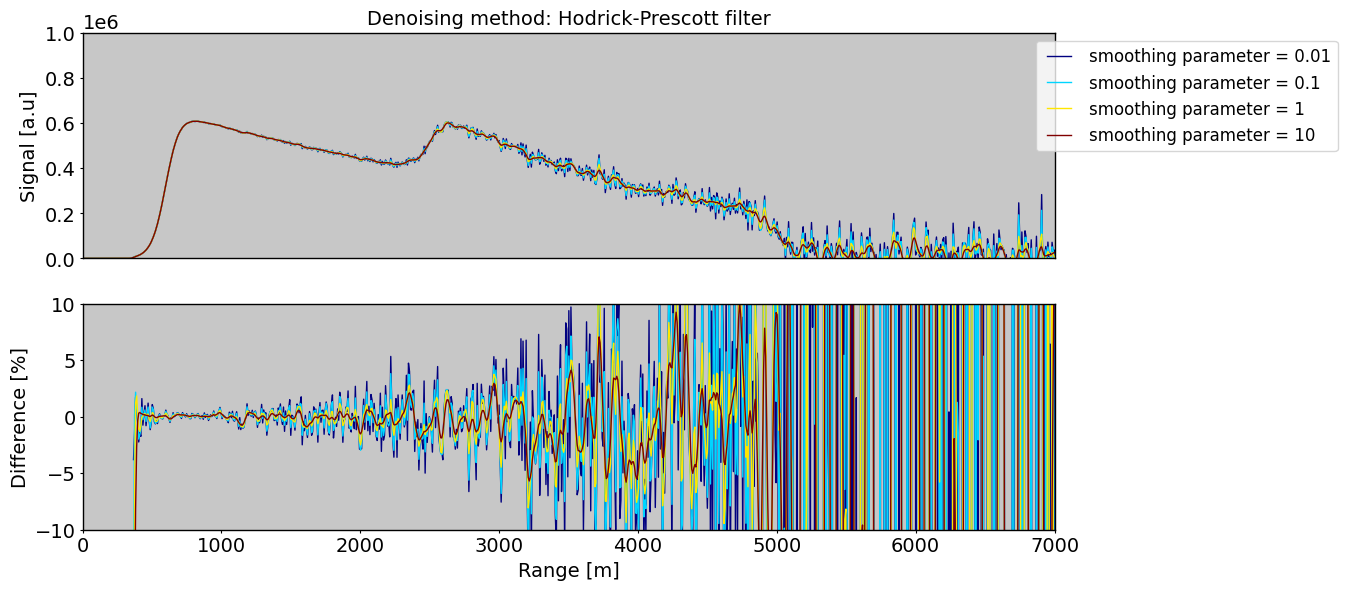

In [19]:
# Analysis of the Hodrick-Prescott filter for different values of the smoothing parameter
from statsmodels.tsa.filters.hp_filter import hpfilter
smoothing_parameter_list = [0.01, 0.1, 1, 10]
colors = color_list(len(smoothing_parameter_list))
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
for smoothing_parameter in smoothing_parameter_list:
    cycle, trend = hpfilter(ss_noise, smoothing_parameter)
    #Axis 1: plot the signal
    ax[0].plot(z, trend * z**2, label = f"smoothing parameter = {smoothing_parameter}", color = colors[smoothing_parameter_list.index(smoothing_parameter)])
    #Axis 2: plot the difference with the original signal
    ax[1].plot(z, 100*(trend  -ss)/ss, label = f"smoothing parameter = {smoothing_parameter}", color = colors[smoothing_parameter_list.index(smoothing_parameter)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize = 12)
ax[0].set_title("Denoising method: Hodrick-Prescott filter")
ax[0].set_xticks([])
ax[0].set_xlabel("")


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\382699370.py:15: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(trend  -ss)/ss, label = f"alpha_1 = {alpha_1}, alpha_2 = {alpha_2}", color = colors[alpha_1_list.index(alpha_1)*len(alpha_2_list) + alpha_2_list.index(alpha_2)])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\382699370.py:15: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(trend  -ss)/ss, label = f"alpha_1 = {alpha_1}, alpha_2 = {alpha_2}", color = colors[alpha_1_list.index(alpha_1)*len(alpha_2_list) + alpha_2_list.index(alpha_2)])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\382699370.py:15: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(trend  -ss)/ss, label = f"alpha_1 = {alpha_1}, alpha_2 = {alpha_2}", color = colors[alpha_1_list.index(alpha_1)*len(alpha_2_list) + alpha_2_list.index(alpha_2)])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\382699370.py:15: RuntimeWarning: divi

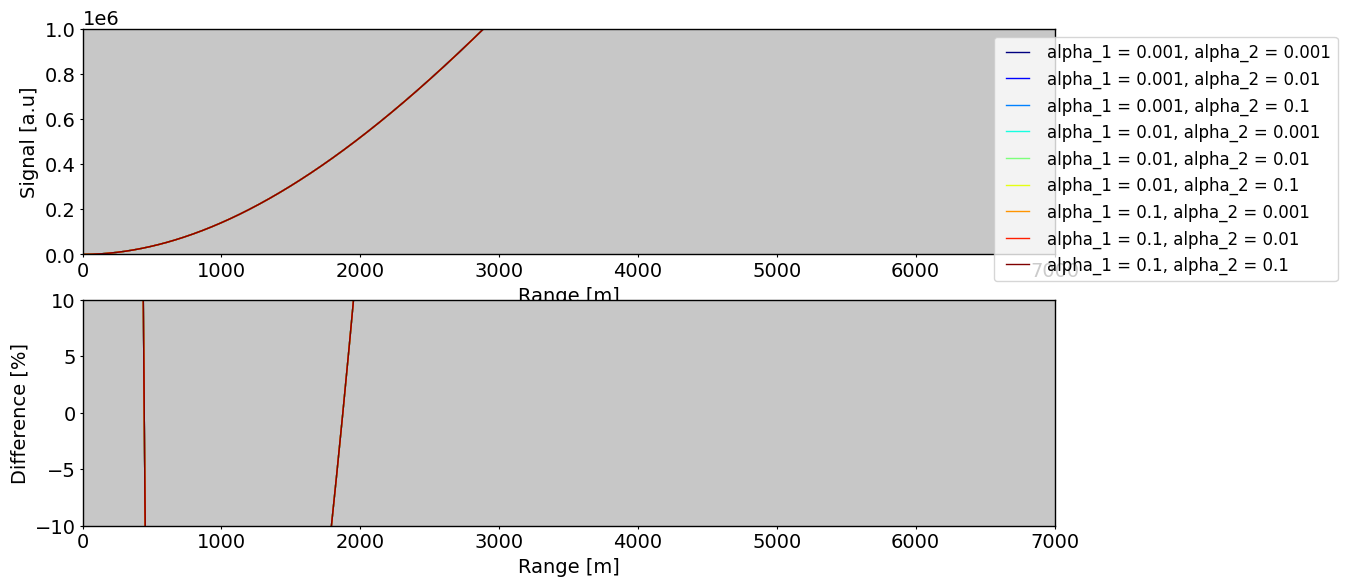

In [20]:
#Analysis of the Bayesian Ridge filter for different values of the alpha_1 and alpha_2 parameters
from sklearn.linear_model import BayesianRidge
alpha_1_list = [1e-3, 1e-2, 1e-1]
alpha_2_list = [1e-3, 1e-2, 1e-1]
colors = color_list(len(alpha_1_list)*len(alpha_2_list))
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
for alpha_1 in alpha_1_list:
    for alpha_2 in alpha_2_list:
        clf = BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2)
        clf.fit(z.reshape(-1, 1), ss_noise)
        trend = clf.predict(z.reshape(-1, 1))
        #Axis 1: plot the signal
        ax[0].plot(z, trend * z**2, label = f"alpha_1 = {alpha_1}, alpha_2 = {alpha_2}", color = colors[alpha_1_list.index(alpha_1)*len(alpha_2_list) + alpha_2_list.index(alpha_2)])
        #Axis 2: plot the difference with the original signal
        ax[1].plot(z, 100*(trend  -ss)/ss, label = f"alpha_1 = {alpha_1}, alpha_2 = {alpha_2}", color = colors[alpha_1_list.index(alpha_1)*len(alpha_2_list) + alpha_2_list.index(alpha_2)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))   
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize = 12)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6396\3544033928.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(z, 100*(trend  -ss)/ss, label = f"smoothing parameter = {smoothing_parameter}", color = colors[smoothing_parameter_list.index(smoothing_parameter)])


Text(0.5, 0, '')

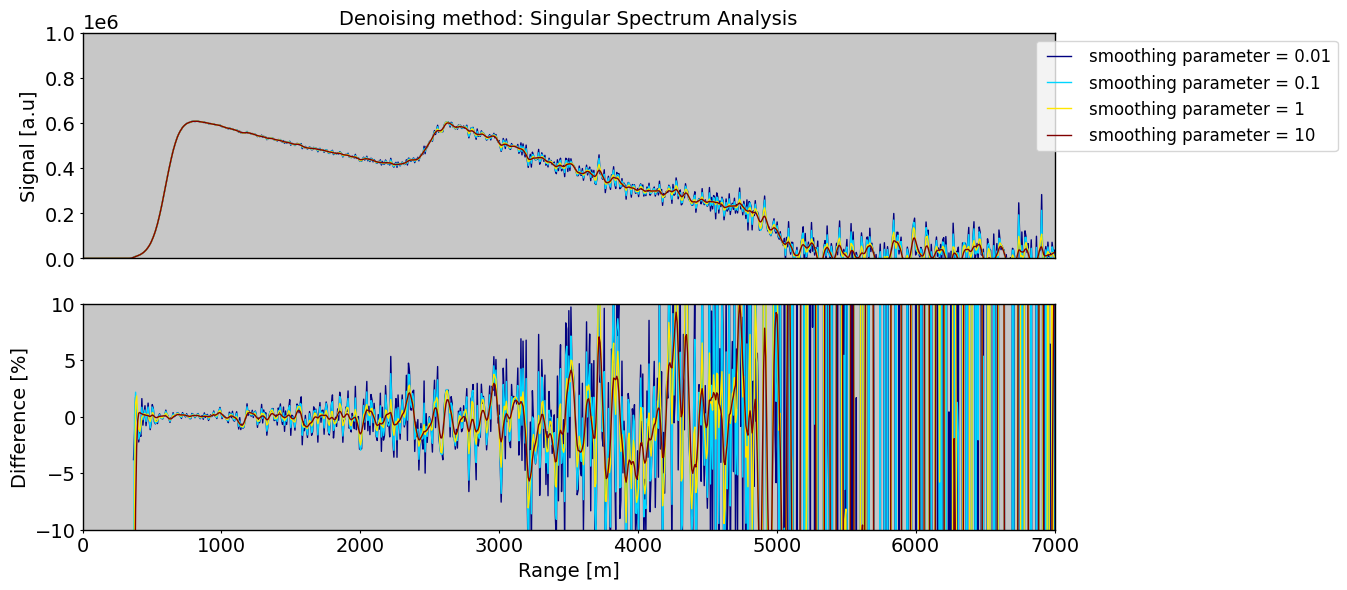

In [21]:
#Analysis of singular spectrum analysis for different values of the window size
from statsmodels.tsa.filters.hp_filter import hpfilter
smoothing_parameter_list = [0.01, 0.1, 1, 10]
colors = color_list(len(smoothing_parameter_list))
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 7))
for smoothing_parameter in smoothing_parameter_list:
    cycle, trend = hpfilter(ss_noise, smoothing_parameter)
    #Axis 1: plot the signal
    ax[0].plot(z, trend * z**2, label = f"smoothing parameter = {smoothing_parameter}", color = colors[smoothing_parameter_list.index(smoothing_parameter)])
    #Axis 2: plot the difference with the original signal
    ax[1].plot(z, 100*(trend  -ss)/ss, label = f"smoothing parameter = {smoothing_parameter}", color = colors[smoothing_parameter_list.index(smoothing_parameter)])
ax[0].set(ylabel="Signal [a.u]",xlabel="Range [m]")
ax[1].set(ylabel="Difference [%]",xlabel="Range [m]")
ax[0].set_ylim((0, 1e6))
ax[0].set_xlim((0, 7000))
ax[1].set_ylim((-10, 10))
ax[1].set_xlim((0, 7000))
ax[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize = 12)
ax[0].set_title("Denoising method: Singular Spectrum Analysis")
ax[0].set_xticks([])
ax[0].set_xlabel("")


In [22]:
params['ecmwf_data']

,height,temperature,pressure
0,7.5,300.280121,90794.773438
1,15.0,300.020447,90717.554688
2,22.5,299.760742,90640.328125
3,30.0,299.501038,90563.101562
4,37.5,299.322479,90485.906250
...,...,...,...
2661,19965.0,214.682556,4951.504883
2662,19972.5,214.702408,4945.785645
2663,19980.0,214.722260,4940.066895
2664,19987.5,214.742111,4934.347656
